In [6]:
# Etapa 001 - - - - importar CSV
from pathlib import Path
import pandas as pd
CSV_PATH = "https://raw.githubusercontent.com/regis-zang/TrbFiap25_Cap05/main/sample/Gastos_Publicidade_MelhoresCompras.csv"

In [8]:
# Etapa 002 - - - - importar CSV
df_raw = pd.read_csv(CSV_PATH)

In [4]:
# Etapa 003- - - Exibindo Estrutura
print(df_raw.shape)
df_raw.head()

(200, 5)


,Ano,Mes,Tipo de Midia,Gastos com Publicidade (em R$),Previsao Inicial de Aumento de Vendas (em mil unidades)
0,2022,1,Paginas web,87000,1000
1,2022,1,Redes sociais,120000,800
2,2022,1,TV,250000,1500
3,2022,1,Jornal,110000,730
4,2022,1,Revista,40000,360


In [9]:
#Etapa 004 - - - Normalizando Dados
import unicodedata
def _norm(s: str) -> str:
    s = s.strip().lower()
    s = ''.join(ch for ch in unicodedata.normalize('NFD', s) if unicodedata.category(ch) != 'Mn')
    s = s.replace('-', ' ').replace('/', ' ')
    return ' '.join(s.split())

normcols = {_norm(c): c for c in df_raw.columns}

def pick(*opts):
    for o in opts:
        if o in normcols:
            return normcols[o]
    raise KeyError(f"Não achei nenhuma coluna: {opts}")

COL_ANO   = pick('ano')
COL_MES   = pick('mes')
COL_MIDIA = pick('tipo de midia', 'tipo de midia ')
COL_GASTO = pick('gastos com publicidade (em r$)', 'gastos com publicidade em r$', 'gastos com publicidade')
COL_ALVO  = pick('previsao inicial de aumento de vendas (em mil unidades)',
                 'previsao inicial de aumento de vendas em mil unidades')

df = df_raw[[COL_ANO, COL_MES, COL_MIDIA, COL_GASTO, COL_ALVO]].copy()
df.columns = ["ano", "mes", "tipo_midia", "gasto", "aumento_vendas_mil"]

for c in ["ano", "mes", "gasto", "aumento_vendas_mil"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(df.shape)
df.head()

(200, 5)


,ano,mes,tipo_midia,gasto,aumento_vendas_mil
0,2022,1,Paginas web,87000.0,1000
1,2022,1,Redes sociais,120000.0,800
2,2022,1,TV,250000.0,1500
3,2022,1,Jornal,110000.0,730
4,2022,1,Revista,40000.0,360


In [10]:
# Etapa 005 - - - Checagem de Problemas
### Atenção aos 3 `NaN` em `gasto`
print("NA por coluna:")

print(df.isna().sum())
### Atenção aos 3 `NaN` em `gasto`
print("\nDescribe numérico:")
display(df.describe())
### Atenção aos 3 lista de valores dimensionais
print("\nValores únicos de tipo_midia:")
sorted(df["tipo_midia"].dropna().unique())

NA por coluna:
ano                   0
mes                   0
tipo_midia            0
gasto                 3
aumento_vendas_mil    0
dtype: int64

Describe numérico:


,ano,mes,gasto,aumento_vendas_mil
count,200.000000,200.000000,197.000000,200.000000
mean,2022.920000,5.810000,156779.096447,1655.360000
std,0.797987,3.327048,76315.098019,1106.972207
min,2022.000000,1.000000,11000.000000,200.000000
25%,2022.000000,3.000000,100800.000000,822.000000
50%,2023.000000,5.500000,140000.000000,1400.000000
75%,2024.000000,8.250000,210000.000000,2132.000000
max,2024.000000,12.000000,335664.000000,5310.000000



Valores únicos de tipo_midia:


['Google',
 'Instagram',
 'Jornal',
 'Paginas web',
 'Radio',
 'Redes sociais',
 'Revista',
 'TV']

In [11]:
# Etapa 006 - - - Separa colunas para analises
def slug(s: str) -> str:
    s2 = ''.join(ch for ch in unicodedata.normalize('NFD', str(s).lower()) if unicodedata.category(ch) != 'Mn')
    return s2.replace(' ', '_')

midias = sorted(df["tipo_midia"].dropna().unique().tolist())
for m in midias:
    col = f"gasto_{slug(m)}"
    df[col] = (df["gasto"].where(df["tipo_midia"] == m, 0.0)).astype(float)

mes_dummies = pd.get_dummies(df["mes"], prefix="mes", drop_first=True)
df_feat = pd.concat([df, mes_dummies], axis=1)
df_feat["ano_trend"] = df_feat["ano"]

# Conjuntos de features que vamos comparar (A/B/C)
feat_A = [c for c in df_feat.columns if c.startswith("gasto_")]
feat_B = feat_A + [c for c in df_feat.columns if c.startswith("mes_")]
feat_C = feat_B + ["ano_trend"]
candidatos = {
    "A_gastos_por_midia": feat_A,
    "B_gastos_e_mes":     feat_B,
    "C_gastos_mes_ano":   feat_C,
}
y = df_feat["aumento_vendas_mil"].values

{nome: len(cols) for nome, cols in candidatos.items()}

{'A_gastos_por_midia': 8, 'B_gastos_e_mes': 19, 'C_gastos_mes_ano': 20}

Top correlações absolutas com o alvo:


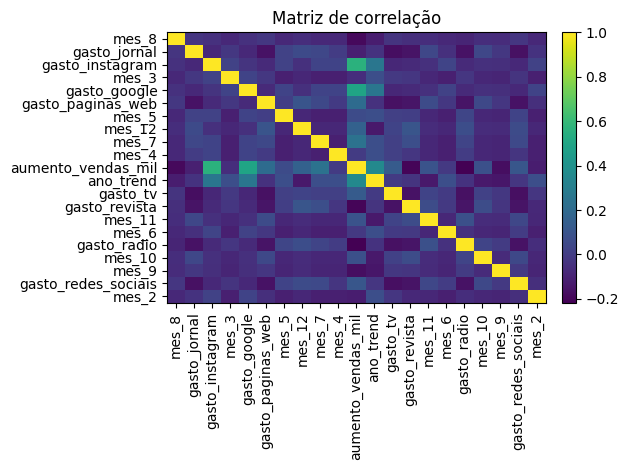

In [12]:
# Etapa 007 - - - Analise Cruzada
import numpy as np
import matplotlib.pyplot as plt

corr_cols = list(set(feat_C + ["aumento_vendas_mil"]))
df_corr = df_feat[corr_cols].corr(numeric_only=True)

print("Top correlações absolutas com o alvo:")
abs(df_corr["aumento_vendas_mil"]).sort_values(ascending=False).head(10)

# Heatmap simples (sem seaborn)
plt.figure()
im = plt.imshow(df_corr.values, aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(df_corr.columns)), df_corr.columns, rotation=90)
plt.yticks(range(len(df_corr.index)), df_corr.index)
plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()


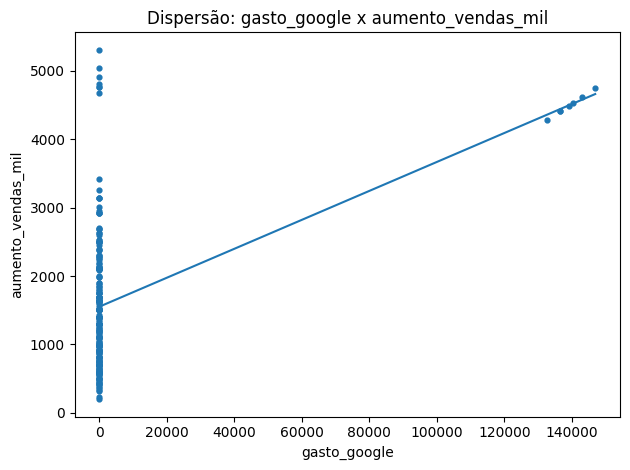

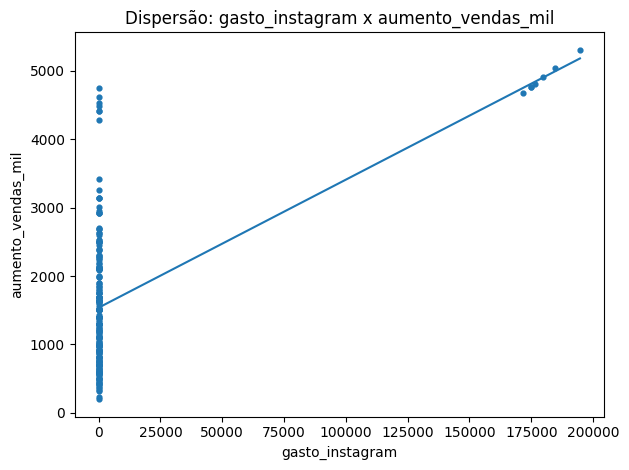

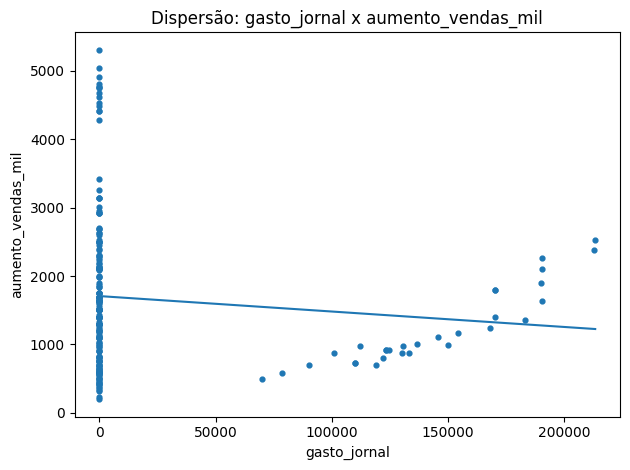

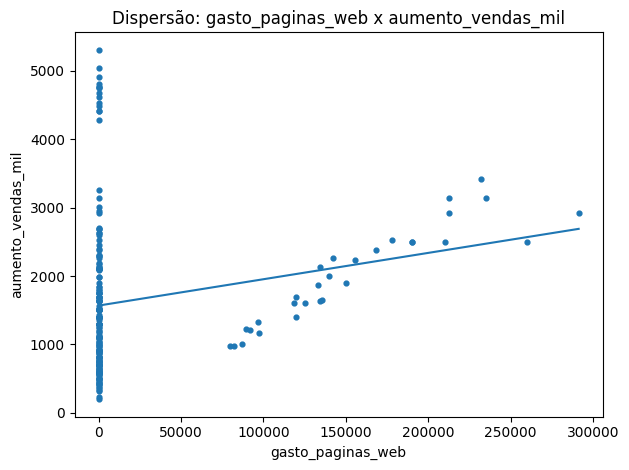

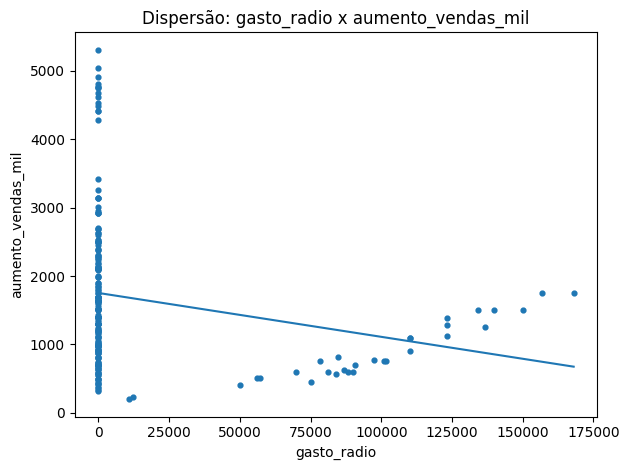

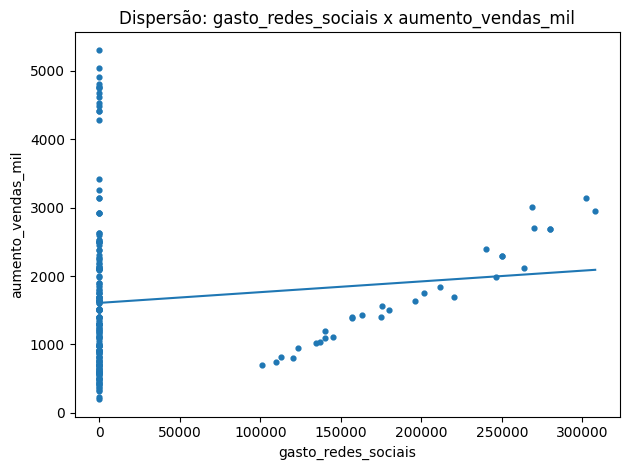

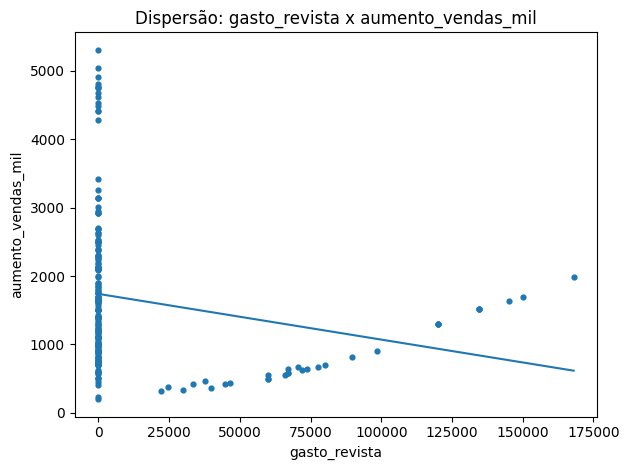

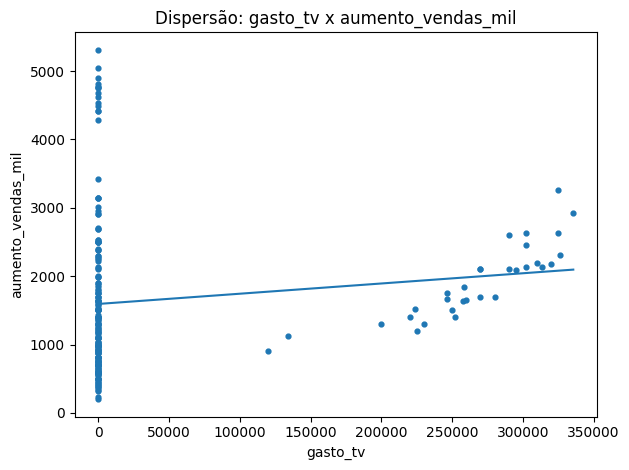

In [13]:
# Etapa 008 - - - Analise Cruzada
for col in feat_A:
    x = df_feat[col].values
    y_ = df_feat["aumento_vendas_mil"].values

    plt.figure()
    plt.scatter(x, y_, s=12)
    if np.nanmax(x) > 0:
        m, b = np.polyfit(x[~np.isnan(x)], y_[~np.isnan(x)], 1)  # tendência linear
        xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        plt.plot(xs, m*xs + b)
    plt.xlabel(col); plt.ylabel("aumento_vendas_mil")
    plt.title(f"Dispersão: {col} x aumento_vendas_mil")
    plt.tight_layout()
    plt.show()


In [15]:
# Etapa 009 - - - Treina um modelo de Regressão Linear
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

TARGET = "aumento_vendas_mil"

def limpar_Xy(cols, df_base, target=TARGET):
    """Seleciona colunas, remove NaN/Inf de X e y e retorna matrizes limpas."""
    use_cols = [c for c in cols if c in df_base.columns]
    if not use_cols:
        return None, None, []

    X = df_base[use_cols].copy()
    y = df_base[target].copy()

    # Remove Inf e NaN
    X = X.replace([np.inf, -np.inf], np.nan)
    y = y.replace([np.inf, -np.inf], np.nan)
    mask = X.notna().all(axis=1) & y.notna()
    X = X.loc[mask]
    y = y.loc[mask]

    # Converte para arrays
    Xv = X.values
    yv = y.values

    return Xv, yv, use_cols

def avaliar_cv(X, y, k=5, seed=42):
    """Avalia R² em CV, ajustando k ao número de amostras válidas."""
    n = len(y)
    if n < 3:
        # muito pouco dado para CV
        return np.nan, np.nan
    k_eff = min(k, max(2, n - 1))  # garante pelo menos 2 folds e não estoura n
    kf = KFold(n_splits=k_eff, shuffle=True, random_state=seed)
    model = LinearRegression()
    scores = cross_val_score(model, X, y, cv=kf, scoring="r2", error_score=np.nan)
    return np.nanmean(scores), np.nanstd(scores)

# 1) Saneia listas de features
candidatos_sanit = {}
for nome, cols in candidatos.items():
    existentes = [c for c in cols if c in df_feat.columns]
    faltando   = sorted(set(cols) - set(existentes))
    if faltando:
        print(f"[AVISO] {nome}: ignorando colunas ausentes -> {faltando}")
    if existentes:
        candidatos_sanit[nome] = existentes

if not candidatos_sanit:
    raise ValueError("Nenhuma especificação com features válidas.")

# 2) Loop nas especificações com limpeza de X/y e CV
resultados = []
for nome, cols in candidatos_sanit.items():
    X, y_valid, cols_ok = limpar_Xy(cols, df_feat, target=TARGET)
    if X is None or len(y_valid) < 3:
        print(f"[AVISO] {nome}: sem dados suficientes após limpeza. Pulando.")
        continue
    m, s = avaliar_cv(X, y_valid, k=5, seed=42)
    resultados.append({
        "modelo": nome,
        "n_features": len(cols_ok),
        "n_amostras_validas": len(y_valid),
        "r2_cv_mean": m,
        "r2_cv_std": s
    })

if not resultados:
    raise ValueError("Todas as especificações falharam por falta de dados válidos. Verifique NaNs/Inf no dataset.")

df_result = pd.DataFrame(resultados).sort_values("r2_cv_mean", ascending=False).reset_index(drop=True)
df_result



,modelo,n_features,n_amostras_validas,r2_cv_mean,r2_cv_std
0,C_gastos_mes_ano,20,197,0.958823,0.015656
1,B_gastos_e_mes,19,197,0.952979,0.015996
2,A_gastos_por_midia,8,197,0.951637,0.011124


In [16]:
# Etapa 010 - - - Ajustando modelo vencedor

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# Seleciona a melhor linha do resultado
best_row = df_result.iloc[0]
best_name = best_row["modelo"]
best_cols = candidatos[best_name]

print(f"Melhor especificação: {best_name} (features={len(best_cols)})")
print("-"*70)

# Limpeza dos dados novamente
X, y_valid, cols_ok = limpar_Xy(best_cols, df_feat, target="aumento_vendas_mil")

# Treino final
model = LinearRegression().fit(X, y_valid)
y_pred = model.predict(X)

# Métricas in-sample
r2_in  = r2_score(y_valid, y_pred)
rmse_in = np.sqrt(mean_squared_error(y_valid, y_pred))

print({
    "best_model": best_name,
    "r2_cv_mean": best_row["r2_cv_mean"],
    "r2_in_sample": r2_in,
    "rmse_in_sample": rmse_in
})

# Coeficientes
coef_df = pd.DataFrame({
    "feature": ["intercept"] + cols_ok,
    "coef": np.concatenate(([model.intercept_], model.coef_))
})
coef_df.head(15)


Melhor especificação: C_gastos_mes_ano (features=20)
----------------------------------------------------------------------
{'best_model': 'C_gastos_mes_ano', 'r2_cv_mean': np.float64(0.9588232522743872), 'r2_in_sample': 0.976455552614104, 'rmse_in_sample': np.float64(170.2604187291558)}


,feature,coef
0,intercept,-209570.253167
1,gasto_google,0.029223
2,gasto_instagram,0.024893
3,gasto_jornal,0.006013
4,gasto_paginas_web,0.010214
5,gasto_radio,0.005329
6,gasto_redes_sociais,0.006963
7,gasto_revista,0.005695
8,gasto_tv,0.005798
9,mes_2,35.126499


,midia,unid_por_R$1000,coef_mil_por_R$1
0,google,29.22,0.029223
1,instagram,24.89,0.024893
2,paginas web,10.21,0.010214
3,redes sociais,6.96,0.006963
4,jornal,6.01,0.006013
5,tv,5.80,0.005798
6,revista,5.69,0.005695
7,radio,5.33,0.005329


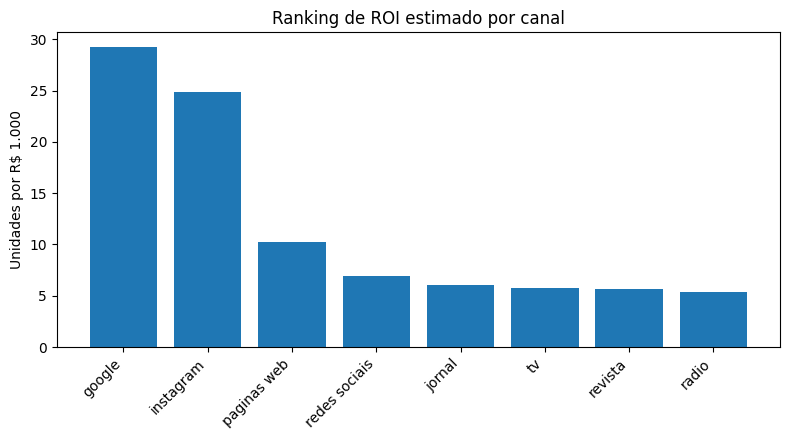

Top 3 canais por retorno estimado (unidades por R$ 1.000): google, instagram, paginas web


from matplotlib import pyplot as plt
roi_df['unid_por_R$1000'].plot(kind='hist', bins=20, title='unid_por_R$1000')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
roi_df['coef_mil_por_R$1'].plot(kind='hist', bins=20, title='coef_mil_por_R$1')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
roi_df.groupby('midia').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
roi_df.plot(kind='scatter', x='unid_por_R$1000', y='coef_mil_por_R$1', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
roi_df['coef_mil_por_R$1'].plot(kind='line', figsize=(8, 4), title='coef_mil_por_R$1')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(roi_df['midia'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(roi_df, x='unid_por_R$1000', y='midia', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(roi_df['midia'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(roi_df, x='coef_mil_por_R$1', y='midia', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [17]:
# === Célula 17 — ROI por canal (unidades por R$ 1000) + gráfico de barras ===
# Etapa 011 - - - ROI por canal  e analytics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# filtra apenas coeficientes ligados a gasto_*
roi_rows = []
for f, c in zip(cols_ok, model.coef_):
    if f.startswith("gasto_"):
        midia = f.replace("gasto_", "").replace("_", " ")
        # coeficiente está em "mil unidades por R$1"
        # multiplicamos por 1000 para "unidades por R$1000"
        unidades_por_1000 = c * 1000
        roi_rows.append((midia, unidades_por_1000, c))

roi_df = pd.DataFrame(roi_rows, columns=["midia", "unid_por_R$1000", "coef_mil_por_R$1"])
roi_df = roi_df.sort_values("unid_por_R$1000", ascending=False).reset_index(drop=True)

# arredondar para apresentação
roi_df["unid_por_R$1000"] = roi_df["unid_por_R$1000"].round(2)
roi_df["coef_mil_por_R$1"] = roi_df["coef_mil_por_R$1"].round(6)

display(roi_df)

# Gráfico de barras (sem definir cores)
plt.figure(figsize=(8, 4.5))
plt.bar(roi_df["midia"], roi_df["unid_por_R$1000"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Unidades por R$ 1.000")
plt.title("Ranking de ROI estimado por canal")
plt.tight_layout()
plt.show()

# Texto curto para o relatório
top3 = ", ".join(roi_df.head(3)["midia"].tolist())
print(f"Top 3 canais por retorno estimado (unidades por R$ 1.000): {top3}")


{'contexto': 'dados limpos do treino final', 'n_amostras': 197, 'R2': 0.9765, 'RMSE': np.float64(170.2604), 'MAE': 114.457}


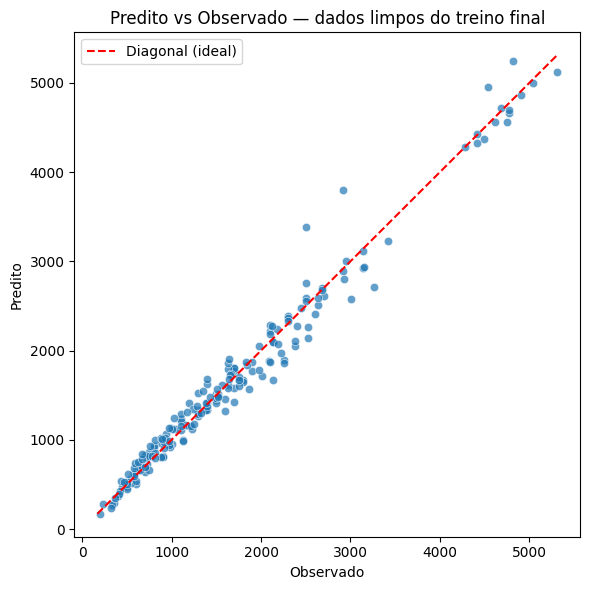

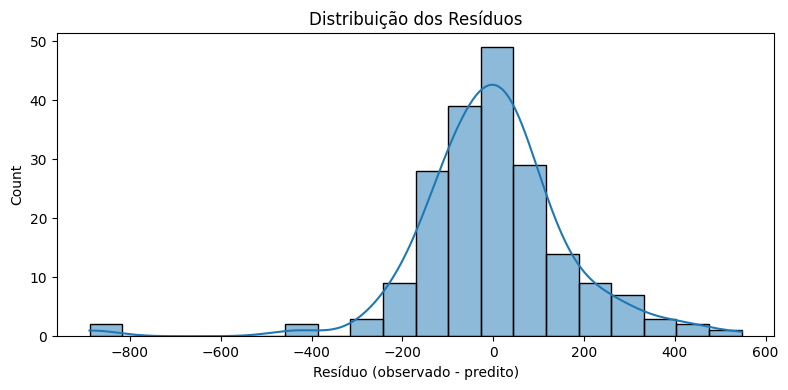

Resumo dos resíduos:
count    197.000
mean       0.000
std      170.694
min     -889.017
25%      -83.315
50%        1.068
75%       74.442
max      547.148
dtype: float64


In [18]:

# Etapa 012 - - -Extra: Validação do modelo (Predito vs Observado, Resíduos e Métricas)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Use os dados LIMPOS usados no treino final (da Célula 16):
X_plot = X          # mesma matriz usada no .fit()
y_plot = y_valid    # mesmo alvo usado no .fit()

# Predições e métricas
y_pred = model.predict(X_plot)
r2   = r2_score(y_plot, y_pred)
rmse = np.sqrt(mean_squared_error(y_plot, y_pred))
mae  = mean_absolute_error(y_plot, y_pred)

print({"contexto": "dados limpos do treino final",
       "n_amostras": len(y_plot),
       "R2": round(r2, 4), "RMSE": round(rmse, 4), "MAE": round(mae, 4)})

# Predito vs Observado
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_plot, y=y_pred, alpha=0.7)
mn, mx = float(min(y_plot.min(), y_pred.min())), float(max(y_plot.max(), y_pred.max()))
plt.plot([mn, mx], [mn, mx], 'r--', label='Diagonal (ideal)')
plt.xlabel("Observado")
plt.ylabel("Predito")
plt.title("Predito vs Observado — dados limpos do treino final")
plt.legend()
plt.tight_layout()
plt.show()

# Resíduos
residuos = y_plot - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuos, bins=20, kde=True)
plt.xlabel("Resíduo (observado - predito)")
plt.title("Distribuição dos Resíduos")
plt.tight_layout()
plt.show()

print("Resumo dos resíduos:")
print(pd.Series(residuos).describe().round(3))


{'n_amostras_validas': 197, 'n_features': 20}
{'contexto': 'holdout (20%)', 'R2': 0.9608, 'RMSE': np.float64(219.0079), 'MAE': 144.2297}


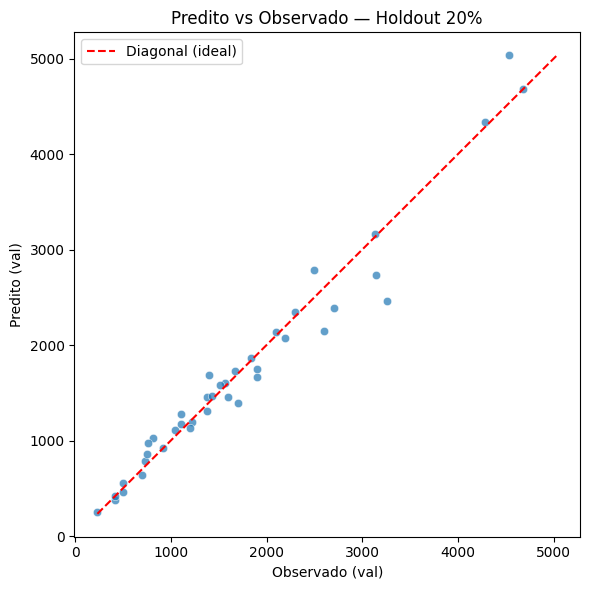

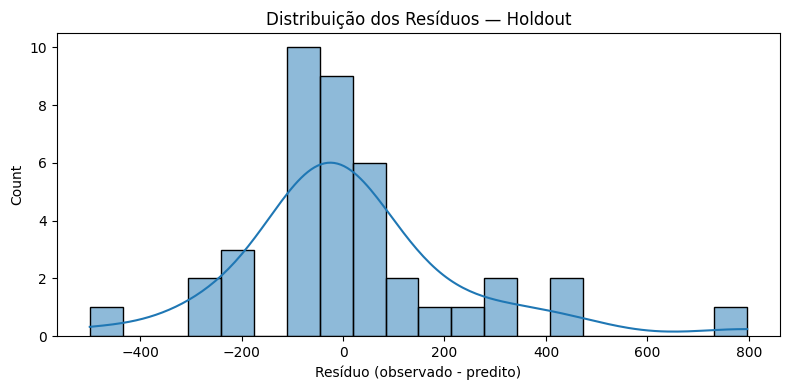

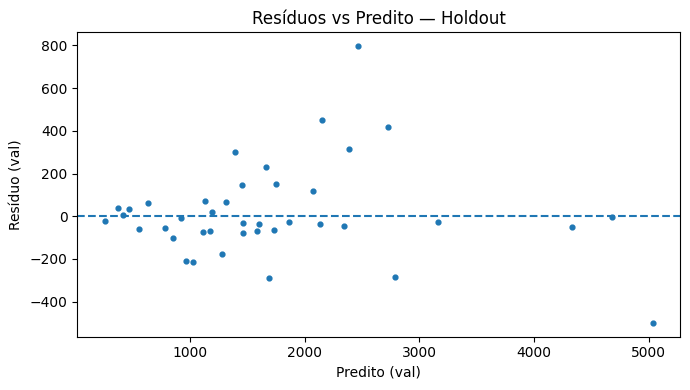

Resumo dos resíduos (holdout):
count     40.000
mean      17.260
std      221.108
min     -499.130
25%      -70.511
50%      -28.442
75%       68.466
max      796.488
dtype: float64


In [22]:
# === Célula: Treino com holdout (train_test_split) + avaliação no conjunto de validação ===
# Etapa 013 - - -Treino com holdout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 0) Reconstroi X/y limpos para a especificação escolhida (usa funções/variáveis da Célula 15/16)
X_full, y_full, cols_ok = limpar_Xy(best_cols, df_feat, target="aumento_vendas_mil")
print({"n_amostras_validas": len(y_full), "n_features": len(cols_ok)})

# 1) Split 80/20 (holdout)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# 2) Treino no conjunto de treino
model = LinearRegression().fit(X_train, y_train)

# 3) Avaliação no conjunto de validação (holdout)
y_pred = model.predict(X_valid)
r2   = r2_score(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae  = mean_absolute_error(y_valid, y_pred)

print({"contexto": "holdout (20%)", "R2": round(r2, 4), "RMSE": round(rmse, 4), "MAE": round(mae, 4)})

# 4) Gráfico Predito vs Observado
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_valid, y=y_pred, alpha=0.7)
mn, mx = float(min(y_valid.min(), y_pred.min())), float(max(y_valid.max(), y_pred.max()))
plt.plot([mn, mx], [mn, mx], 'r--', label='Diagonal (ideal)')
plt.xlabel("Observado (val)")
plt.ylabel("Predito (val)")
plt.title("Predito vs Observado — Holdout 20%")
plt.legend()
plt.tight_layout()
plt.show()

# 5) Resíduos no holdout
residuos = y_valid - y_pred

plt.figure(figsize=(8, 4))
sns.histplot(residuos, bins=20, kde=True)
plt.xlabel("Resíduo (observado - predito)")
plt.title("Distribuição dos Resíduos — Holdout")
plt.tight_layout()
plt.show()

# (Opcional) Resíduos vs Predito — checa heterocedasticidade
plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuos, s=12)
plt.axhline(0, linestyle="--")
plt.xlabel("Predito (val)")
plt.ylabel("Resíduo (val)")
plt.title("Resíduos vs Predito — Holdout")
plt.tight_layout()
plt.show()

print("Resumo dos resíduos (holdout):")
print(pd.Series(residuos).describe().round(3))


In [31]:
# === Célula 19 — Texto explicativo para Marketing (print em português) ===
# Etapa 014 - - - Criando Markdown para Time de Marketing
import pandas as pd
import numpy as np

# Garante o ranking de ROI com base no modelo atual (treinado no holdout)
roi_rows = []
for f, c in zip(cols_ok, model.coef_):
    if f.startswith("gasto_"):
        midia = f.replace("gasto_", "").replace("_", " ")
        unidades_por_1000 = float(c) * 1000.0  # unidades por R$1.000
        roi_rows.append((midia, unidades_por_1000))

roi_df = pd.DataFrame(roi_rows, columns=["midia", "unid_por_R$1000"]).sort_values("unid_por_R$1000", ascending=False)
top3 = ", ".join(roi_df.head(3)["midia"].tolist())

# Texto amigável para negócio
texto = f"""
Resumo Executivo – ROI de Publicidade (Holdout)
------------------------------------------------
• O modelo de regressão linear foi treinado em 80% dos dados e avaliado nos 20% restantes (holdout).
• Desempenho no holdout:
  - R²: {r2:.3f}  (quanto mais próximo de 1, melhor explicação da variação nas vendas)
  - RMSE: {rmse:.3f} mil unidades  (erro médio de previsão em termos de magnitude)
  - MAE: {mae:.3f} mil unidades  (erro médio absoluto)

O que isso significa:
• O R² indica que o modelo explica uma parcela elevada da variação do aumento de vendas com base nos gastos por canal, mês e tendência de ano.
• Os erros (RMSE/MAE) mostram a ordem de grandeza típica da diferença entre a previsão e o observado no conjunto de validação.

Canais com maior retorno estimado (ROI)
• Ranking por “unidades vendidas por R$ 1.000 investidos” (efeito marginal estimado):
{roi_df.to_string(index=False, formatters={'unid_por_R$1000': lambda v: f"{v:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')})}

Conclusões para Marketing
• Top 3 canais por retorno estimado: {top3}.
• Mantidas as demais variáveis constantes, cada R$ 1.000 investidos nesses canais tende, em média, a gerar o maior aumento de unidades vendidas.
• Recomendação de alocação: priorizar orçamento nos canais líderes, aplicar incrementos graduais (ex.: +10% de verba) e medir o impacto mês a mês (testes A/B ou controle).

Cuidados e próximos passos
• O efeito estimado é “marginal” e assume relação linear; em patamares muito altos de investimento pode ocorrer saturação (não capturada por este modelo).
• Canais recentes podem ter menos histórico, trazendo maior incerteza nas estimativas.
• Próximos passos: testar interações entre canais e/ou termos quadráticos com validação rigorosa para evitar overfitting.
"""

print(texto)



Resumo Executivo – ROI de Publicidade (Holdout)
------------------------------------------------
• O modelo de regressão linear foi treinado em 80% dos dados e avaliado nos 20% restantes (holdout).
• Desempenho no holdout:
  - R²: 0.961  (quanto mais próximo de 1, melhor explicação da variação nas vendas)
  - RMSE: 219.008 mil unidades  (erro médio de previsão em termos de magnitude)
  - MAE: 144.230 mil unidades  (erro médio absoluto)

O que isso significa:
• O R² indica que o modelo explica uma parcela elevada da variação do aumento de vendas com base nos gastos por canal, mês e tendência de ano.
• Os erros (RMSE/MAE) mostram a ordem de grandeza típica da diferença entre a previsão e o observado no conjunto de validação.

Canais com maior retorno estimado (ROI)
• Ranking por “unidades vendidas por R$ 1.000 investidos” (efeito marginal estimado):
        midia unid_por_R$1000
       google           30,31
    instagram           25,30
  paginas web           10,81
redes sociais      

In [32]:
# Etapa 015 — Testes de normalidade dos resíduos
from scipy import stats

# reutiliza resíduos do treino final (Etapa 012) OU do holdout (acima):
# aqui, escolho holdout (mais honesto para validação)
# residuo = res_te
residuos = np.asarray(residuos, dtype=float)  # usa o 'residuos' já criado na Etapa 013

# Shapiro-Wilk
sh_w, sh_p = stats.shapiro(residuos)
print(f"Shapiro-Wilk: W={sh_w:.4f}, p={sh_p:.4g}")

# Kolmogorov-Smirnov contra N(μ, σ)
mu, sigma = np.mean(residuos), np.std(residuos, ddof=1)
ks_stat, ks_p = stats.kstest(residuos, 'norm', args=(mu, sigma))
print(f"Kolmogorov-Smirnov: stat={ks_stat:.4f}, p={ks_p:.4g}")

# Lilliefors (via statsmodels; instala se necessário)
try:
    from statsmodels.stats.diagnostic import lilliefors
except Exception as e:
    try:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "statsmodels"])
        from statsmodels.stats.diagnostic import lilliefors
    except Exception as e2:
        lilliefors = None
        print("Lilliefors indisponível (não foi possível importar/instalar statsmodels).")

if lilliefors is not None:
    lf_stat, lf_p = lilliefors(residuos, dist='norm')
    print(f"Lilliefors: stat={lf_stat:.4f}, p={lf_p:.4g}")

# Nota de leitura:
# p < 0.05 → rejeita normalidade estrita. Em regressão linear, leve desvio raramente é crítico
# quando n é razoável e não há viés forte. Registre a observação no relatório.

Shapiro-Wilk: W=0.8951, p=0.001381
Kolmogorov-Smirnov: stat=0.1793, p=0.1347
Lilliefors: stat=0.1793, p=0.002512


In [37]:
# === FIX: garantir X e y numéricos antes do OLS ===
# Etapaa 016 - Parte 001- ajustando dados para analise
import numpy as np, pandas as pd, statsmodels.api as sm

TARGET = "aumento_vendas_mil"

# Descobrir as colunas escolhidas no melhor modelo
if "cols_ok" in globals() and cols_ok:
    best_cols = list(cols_ok)
else:
    best_name = df_result.iloc[0]["modelo"]
    best_cols = list(candidatos[best_name])

# Montar X e y a partir do df_feat
X_df = df_feat.loc[:, best_cols].copy()
y_ser = df_feat.loc[:, TARGET].copy()

# DEBUG opcional: ver colunas não numéricas
non_num = [c for c in X_df.columns if not np.issubdtype(X_df[c].dtype, np.number)]
print("Colunas não numéricas em X:", non_num)

# Coagir tudo para numérico (strings/Int64/boolean -> float), virando NaN se não converter
X_df = X_df.apply(pd.to_numeric, errors="coerce")
y_ser = pd.to_numeric(y_ser, errors="coerce")

# Remover linhas com NaN após coerção
mask = X_df.notna().all(axis=1) & y_ser.notna()
X_df = X_df.loc[mask].astype(float)
y_ser = y_ser.loc[mask].astype(float)

# Guardar como arrays (se outras células precisarem)
X_all = X_df.to_numpy(dtype=float)
y_all = y_ser.to_numpy(dtype=float)
cols_ok = list(X_df.columns)

# DataFrame para statsmodels, com constante
Xsm = sm.add_constant(X_df, has_constant="add")

# Ajustar OLS (agora sem erro de dtype)
ols = sm.OLS(y_ser, Xsm).fit()

print(f"X_all.shape={X_all.shape}, y_all.shape={y_all.shape}")
print("OLS pronto (dados coeridos para float).")

Colunas não numéricas em X: ['mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']
X_all.shape=(197, 20), y_all.shape=(197,)
OLS pronto (dados coeridos para float).


In [36]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Breusch-Pagan
bp_stat, bp_p, _, _ = het_breuschpagan(ols.resid, Xsm.values)
print(f"Breusch-Pagan: stat={bp_stat:.3f}  p={bp_p:.4g}")

# Durbin-Watson
print(f"Durbin-Watson: {durbin_watson(ols.resid):.3f}")

# VIF
vif_df = pd.DataFrame({
    "feature": ["const"] + cols_ok,
    "VIF": [variance_inflation_factor(np.column_stack([np.ones(len(X_all)), X_all]), i)
            for i in range(len(cols_ok)+1)]
}).sort_values("VIF", ascending=False)
display(vif_df.head(10))

Breusch-Pagan: stat=80.890  p=2.771e-09
Durbin-Watson: 1.869


,feature,VIF
0,const,9.842470e+06
6,gasto_redes_sociais,6.817230e+00
7,gasto_revista,6.796815e+00
4,gasto_paginas_web,6.747407e+00
5,gasto_radio,6.693874e+00
3,gasto_jornal,6.664971e+00
8,gasto_tv,6.616089e+00
19,mes_12,2.991964e+00
14,mes_7,2.812873e+00
1,gasto_google,2.590215e+00


In [38]:
# Etapa 017 — Comparativo: gastos por mídia + dummies(tipo_midia)
# A: já existe (gastos por mídia)
# D: gastos por mídia + dummies de tipo_midia
X_gastos = df_feat[[c for c in df_feat.columns if c.startswith("gasto_")]].copy()
mid_dum = pd.get_dummies(df_feat["tipo_midia"], prefix="mid", drop_first=True)
Xd = pd.concat([X_gastos, mid_dum], axis=1)
y = df_feat["aumento_vendas_mil"]

# Limpeza
Xv = Xd.replace([np.inf, -np.inf], np.nan).dropna()
yv = y.loc[Xv.index].dropna()
Xv = Xv.loc[yv.index]

# CV comparando A vs D
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

def r2_cv(X, y, k=5, seed=42):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    return cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2").mean()

r2_A = r2_cv(X_gastos.loc[Xv.index], yv)
r2_D = r2_cv(Xv, yv)
print({"r2_A_gastos": round(r2_A,4), "r2_D_gastos+dummies": round(r2_D,4)})

{'r2_A_gastos': np.float64(0.9516), 'r2_D_gastos+dummies': np.float64(0.955)}


In [41]:
# Etapa 018 — Simulador de orçamento (usando modelo vencedor)
import pandas as pd
import numpy as np

# pega apenas coeficientes das variáveis gasto_* do modelo final 'model'
roi_rows = []
for f, c in zip(cols_ok, model.coef_):
    if f.startswith("gasto_"):
        midia = f.replace("gasto_", "").replace("_", " ")
        roi_rows.append((midia, c*1000))  # unidades por R$1000
roi_df = pd.DataFrame(roi_rows, columns=["midia", "unid_por_R$1000"]).sort_values("unid_por_R$1000", ascending=False)
display(roi_df)

def prever_vendas_orcamento(orcs_dict, base_mes=None, base_ano=None):
    """
    orcs_dict: {'google': 60000, 'instagram': 30000, 'paginas web': 10000, ...}
               valores em R$
    Retorna aumento de vendas previsto (em unidades), considerando apenas efeito marginal dos gastos.
    Obs: não inclui efeitos sazonais ou intercepto (poderia incluir com cols de mes/ano se desejar).
    """
    total = 0.0
    for midia, verba in orcs_dict.items():
        col = f"gasto_{midia.lower().replace(' ', '_')}"
        # coef em unidades por R$1000
        coef_u_por_1000 = float(roi_df.loc[roi_df["midia"]==midia, "unid_por_R$1000"].values[0])
        total += (verba/1000.0) * coef_u_por_1000
    return total

# Exemplo: distribuir R$100.000 (60/30/10) entre top-3
top3 = roi_df["midia"].head(3).tolist()
orc_exemplo = {top3[0]: 60000, top3[1]: 30000, top3[2]: 10000}
print("Cenário exemplo:", orc_exemplo)
print("Aumento previsto (unid):", round(prever_vendas_orcamento(orc_exemplo)))

,midia,unid_por_R$1000
0,google,30.307261
1,instagram,25.297623
3,paginas web,10.806244
5,redes sociais,7.316140
6,revista,6.800429
2,jornal,6.608699
4,radio,6.388405
7,tv,5.989786


Cenário exemplo: {'google': 60000, 'instagram': 30000, 'paginas web': 10000}
Aumento previsto (unid): 2685


In [42]:
#Tabela de coeficientes com erros robustos (HC3)
import statsmodels.api as sm
rob = sm.OLS(y_ser, Xsm).fit(cov_type="HC3")
rob_summary = rob.summary()
print(rob_summary)

                            OLS Regression Results                            
Dep. Variable:     aumento_vendas_mil   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     496.4
Date:                Fri, 05 Sep 2025   Prob (F-statistic):          1.97e-143
Time:                        02:02:43   Log-Likelihood:                -1291.6
No. Observations:                 197   AIC:                             2625.
Df Residuals:                     176   BIC:                             2694.
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -2.096e+05   4

In [43]:
# Simulador rápido de orçamento (usa coeficientes gasto_*)
roi_rows = []
for f, c in zip(cols_ok, model.coef_):
    if f.startswith("gasto_"):  # unidades por R$ 1.000
        roi_rows.append((f.replace("gasto_","").replace("_"," "), c*1000))
import pandas as pd
roi_df = pd.DataFrame(roi_rows, columns=["midia","unid_por_R$1000"]).sort_values("unid_por_R$1000", ascending=False)
display(roi_df)

def prever_vendas_orcamento(verbas: dict):
    return sum((verba/1000.0)*roi_df.loc[roi_df.midia==midia,"unid_por_R$1000"].values[0]
               for midia, verba in verbas.items())

# exemplo
top3 = roi_df.midia.head(3).tolist()
verbas = {top3[0]:60000, top3[1]:30000, top3[2]:10000}
print("Aumento previsto (unid):", round(prever_vendas_orcamento(verbas)))

,midia,unid_por_R$1000
0,google,30.307261
1,instagram,25.297623
3,paginas web,10.806244
5,redes sociais,7.316140
6,revista,6.800429
2,jornal,6.608699
4,radio,6.388405
7,tv,5.989786


Aumento previsto (unid): 2685
